In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import RobustScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer, make_column_selector

from sklearn.feature_selection import mutual_info_regression

from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

import pickle

# to remove scientific notations
pd.options.display.float_format = '{:.6f}'.format

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import warnings 
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv(r"C:\Users\91630\Downloads\Asteroids.csv")
df.head()

,id,spkid,full_name,pdes,name,prefix,neo,pha,H,diameter,...,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,a0000001,2000001,1 Ceres,1,Ceres,NaN,N,N,3.400000,939.400000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,MBA,0.433010
1,a0000002,2000002,2 Pallas,2,Pallas,NaN,N,N,4.200000,545.000000,...,0.000003,0.000006,0.000009,0.000009,0.000000,0.000000,0.000041,0.000004,MBA,0.359360
2,a0000003,2000003,3 Juno,3,Juno,NaN,N,N,5.330000,246.596000,...,0.000003,0.000017,0.000018,0.000008,0.000000,0.000000,0.000035,0.000003,MBA,0.338480
3,a0000004,2000004,4 Vesta,4,Vesta,NaN,N,N,3.000000,525.400000,...,0.000000,0.000000,0.000000,0.000001,0.000000,0.000000,0.000004,0.000001,MBA,0.399800
4,a0000005,2000005,5 Astraea,5,Astraea,NaN,N,N,6.900000,106.699000,...,0.000003,0.000029,0.000030,0.000008,0.000000,0.000000,0.000035,0.000003,MBA,0.521910


In [4]:
df.shape
df.info()

(958524, 45)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 958524 entries, 0 to 958523
Data columns (total 45 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              958524 non-null  object 
 1   spkid           958524 non-null  int64  
 2   full_name       958524 non-null  object 
 3   pdes            958524 non-null  object 
 4   name            22064 non-null   object 
 5   prefix          18 non-null      object 
 6   neo             958520 non-null  object 
 7   pha             938603 non-null  object 
 8   H               952261 non-null  float64
 9   diameter        136209 non-null  float64
 10  albedo          135103 non-null  float64
 11  diameter_sigma  136081 non-null  float64
 12  orbit_id        958524 non-null  object 
 13  epoch           958524 non-null  float64
 14  epoch_mjd       958524 non-null  int64  
 15  epoch_cal       958524 non-null  float64
 16  equinox         958524 non-null  object 
 17  e         

In [5]:
df.describe()

,spkid,H,diameter,albedo,diameter_sigma,epoch,epoch_mjd,epoch_cal,e,a,...,sigma_q,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,rms
count,958524.000000,952261.000000,136209.000000,135103.000000,136081.000000,958524.000000,958524.000000,958524.000000,958524.000000,958524.000000,...,938602.000000,938602.000000,938602.000000,938602.000000,938602.000000,938598.000000,938602.000000,938602.000000,938598.000000,958522.000000
mean,3810113.988625,16.906411,5.506429,0.130627,0.479184,2458869.281950,58868.781950,20196925.051579,0.156116,2.902143,...,19.829292,1.168449,5.310234,1370061.638910,1369977.226665,21.314529,0.050602,431278021.001535,85258.149804,0.561153
std,6831540.880487,1.790405,9.425164,0.110323,0.782895,701.671573,701.671573,19303.536845,0.092643,39.719503,...,2903.785314,128.223066,1333.381176,915899566.238375,915899068.401433,7197.034023,9.814953,295304579371.806885,27676810.590459,2.745700
min,2000001.000000,-1.100000,0.002500,0.001000,0.000500,2425051.500000,25051.000000,19270620.000000,0.000000,-14702.447872,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2239631.750000,16.100000,2.780000,0.053000,0.180000,2459000.500000,59000.000000,20200531.000000,0.092193,2.387835,...,0.000000,0.000006,0.000036,0.000058,0.000026,0.000000,0.000000,0.000111,0.000018,0.518040
50%,2479262.500000,16.900000,3.972000,0.079000,0.332000,2459000.500000,59000.000000,20200531.000000,0.145002,2.646969,...,0.000000,0.000009,0.000066,0.000105,0.000049,0.000000,0.000000,0.000223,0.000035,0.566280
75%,3752517.750000,17.714000,5.765000,0.190000,0.620000,2459000.500000,59000.000000,20200531.000000,0.200650,3.001932,...,0.000001,0.000016,0.000161,0.000311,0.000172,0.000000,0.000000,0.000814,0.000098,0.613927
max,54017232.000000,33.200000,939.400000,1.000000,140.000000,2459000.500000,59000.000000,20200531.000000,1.855356,33488.895955,...,1015000.000000,55330.000000,1199100.000000,884510000000.000000,884510000000.000000,5509700.000000,7698.800000,285310000000000.000000,19107000000.000000,2686.600000


In [6]:
rename_dict = {
    'id': 'Asteroid_ID',
    'spkid': 'NASA_SPK_ID',
    'full_name': 'Asteroid_Full_Name',
    'pdes': 'Primary_Designation',
    'name': 'Asteroid_Name',
    'prefix': 'Name_Prefix',
    'neo': 'Near_Earth_Object',
    'pha': 'Potentially_Hazardous',
    'H': 'Brightness',
    'diameter': 'Asteroid_Size_km(Diameter)',
    'albedo': 'Reflectivity',
    'diameter_sigma': 'Size_Uncertainty_km',
    'orbit_id': 'Orbit_Solution_ID',
    'epoch': 'Observation_Date',
    'epoch_mjd': 'Observation_Date_MJD',
    'epoch_cal': 'Observation_Date_Calendar',
    'equinox': 'Reference_Frame',
    'e': 'Orbit_Shape',
    'a': 'Orbit_Distance_AU',
    'q': 'Closest_Sun_Distance_AU',
    'i': 'Orbit_Tilt_Degrees',
    'om': 'Orbit_Angle_1_Degrees',
    'w': 'Orbit_Angle_2_Degrees',
    'ma': 'Orbit_Angle_3_Degrees',
    'ad': 'Farthest_Sun_Distance_AU',
    'n': 'Orbit_Speed_Degrees_Per_Day',
    'tp': 'Closest_Sun_Date',
    'tp_cal': 'Closest_Sun_Date_Calendar',
    'per': 'Orbit_Period_Days',
    'per_y': 'Orbit_Period_Years',
    'moid': 'Earth_Closest_Distance_AU',
    'moid_ld': 'Earth_Closest_Distance_Lunar',
    'sigma_e': 'Uncertainty_Orbit_Shape',
    'sigma_a': 'Uncertainty_Orbit_Distance',
    'sigma_q': 'Uncertainty_Closest_Sun_Distance',
    'sigma_i': 'Uncertainty_Orbit_Tilt',
    'sigma_om': 'Uncertainty_Orbit_Angle_1',
    'sigma_w': 'Uncertainty_Orbit_Angle_2',
    'sigma_ma': 'Uncertainty_Orbit_Angle_3',
    'sigma_ad': 'Uncertainty_Farthest_Sun_Distance',
    'sigma_n': 'Uncertainty_Orbit_Speed',
    'sigma_tp': 'Uncertainty_Closest_Sun_Date',
    'sigma_per': 'Uncertainty_Orbit_Period',
    'class': 'Asteroid_Class',
    'rms': 'Measurement_Error'
}

df.rename(columns=rename_dict, inplace=True)

df.head()

,Asteroid_ID,NASA_SPK_ID,Asteroid_Full_Name,Primary_Designation,Asteroid_Name,Name_Prefix,Near_Earth_Object,Potentially_Hazardous,Brightness,Asteroid_Size_km(Diameter),...,Uncertainty_Orbit_Tilt,Uncertainty_Orbit_Angle_1,Uncertainty_Orbit_Angle_2,Uncertainty_Orbit_Angle_3,Uncertainty_Farthest_Sun_Distance,Uncertainty_Orbit_Speed,Uncertainty_Closest_Sun_Date,Uncertainty_Orbit_Period,Asteroid_Class,Measurement_Error
0,a0000001,2000001,1 Ceres,1,Ceres,NaN,N,N,3.400000,939.400000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,MBA,0.433010
1,a0000002,2000002,2 Pallas,2,Pallas,NaN,N,N,4.200000,545.000000,...,0.000003,0.000006,0.000009,0.000009,0.000000,0.000000,0.000041,0.000004,MBA,0.359360
2,a0000003,2000003,3 Juno,3,Juno,NaN,N,N,5.330000,246.596000,...,0.000003,0.000017,0.000018,0.000008,0.000000,0.000000,0.000035,0.000003,MBA,0.338480
3,a0000004,2000004,4 Vesta,4,Vesta,NaN,N,N,3.000000,525.400000,...,0.000000,0.000000,0.000000,0.000001,0.000000,0.000000,0.000004,0.000001,MBA,0.399800
4,a0000005,2000005,5 Astraea,5,Astraea,NaN,N,N,6.900000,106.699000,...,0.000003,0.000029,0.000030,0.000008,0.000000,0.000000,0.000035,0.000003,MBA,0.521910


### Checking for missing values

In [7]:
df.isna().sum()/len(df)*100

Asteroid_ID                          0.000000
NASA_SPK_ID                          0.000000
Asteroid_Full_Name                   0.000000
Primary_Designation                  0.000000
Asteroid_Name                       97.698128
Name_Prefix                         99.998122
Near_Earth_Object                    0.000417
Potentially_Hazardous                2.078300
Brightness                           0.653400
Asteroid_Size_km(Diameter)          85.789714
Reflectivity                        85.905100
Size_Uncertainty_km                 85.803068
Orbit_Solution_ID                    0.000000
Observation_Date                     0.000000
Observation_Date_MJD                 0.000000
Observation_Date_Calendar            0.000000
Reference_Frame                      0.000000
Orbit_Shape                          0.000000
Orbit_Distance_AU                    0.000000
Closest_Sun_Distance_AU              0.000000
Orbit_Tilt_Degrees                   0.000000
Orbit_Angle_1_Degrees             

#### Non-Useful Columns:
+ Asteroid_ID, NASA_SPK_ID, Asteroid_Full_Name, Primary_Designation, Asteroid_Name, Name_Prefix: Identifiers or text fields with no predictive power.
+ Size_Uncertainty_km, Uncertainty_Orbit_Shape to Uncertainty_Orbit_Period, Measurement_Error: Metadata about measurement accuracy.
+ Orbit_Solution_ID, Observation_Date, Observation_Date_MJD, Observation_Date_Calendar, Reference_Frame, Closest_Sun_Date, Closest_Sun_Date_Calendar: Metadata or timestamps.

#### Redundant Columns:
+ Dropped Earth_Closest_Distance_Lunar (kept Earth_Closest_Distance_AU).+ Dropped Orbit_Period_Years (kept Orbit_Period_Days).

In [8]:
# List of non-useful columns
non_useful_columns = [
    'Asteroid_ID', 'NASA_SPK_ID', 'Asteroid_Full_Name', 'Primary_Designation',
    'Asteroid_Name', 'Name_Prefix', 'Size_Uncertainty_km', 'Orbit_Solution_ID',
    'Observation_Date', 'Observation_Date_MJD', 'Observation_Date_Calendar',
    'Reference_Frame', 'Closest_Sun_Date', 'Closest_Sun_Date_Calendar',
    'Uncertainty_Orbit_Shape', 'Uncertainty_Orbit_Distance', 'Uncertainty_Closest_Sun_Distance',
    'Uncertainty_Orbit_Tilt', 'Uncertainty_Orbit_Angle_1', 'Uncertainty_Orbit_Angle_2',
    'Uncertainty_Orbit_Angle_3', 'Uncertainty_Farthest_Sun_Distance', 'Uncertainty_Orbit_Speed',
    'Uncertainty_Closest_Sun_Date', 'Uncertainty_Orbit_Period', 'Measurement_Error'
]

# Drop non-useful columns
df.drop(columns=non_useful_columns, inplace=True)

# Drop one of the redundant columns (keep Earth_Closest_Distance_AU, drop Lunar)
df.drop(columns=['Earth_Closest_Distance_Lunar', 'Orbit_Period_Years'], inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 958524 entries, 0 to 958523
Data columns (total 17 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Near_Earth_Object            958520 non-null  object 
 1   Potentially_Hazardous        938603 non-null  object 
 2   Brightness                   952261 non-null  float64
 3   Asteroid_Size_km(Diameter)   136209 non-null  float64
 4   Reflectivity                 135103 non-null  float64
 5   Orbit_Shape                  958524 non-null  float64
 6   Orbit_Distance_AU            958524 non-null  float64
 7   Closest_Sun_Distance_AU      958524 non-null  float64
 8   Orbit_Tilt_Degrees           958524 non-null  float64
 9   Orbit_Angle_1_Degrees        958524 non-null  float64
 10  Orbit_Angle_2_Degrees        958524 non-null  float64
 11  Orbit_Angle_3_Degrees        958523 non-null  float64
 12  Farthest_Sun_Distance_AU     958520 non-null  float64
 13 

### Handling missing values

In [9]:
# Dropping all the rows that doesn't have a value for diameter
df.dropna(subset=['Asteroid_Size_km(Diameter)'],inplace=True)

In [10]:
df.shape

(136209, 17)

In [11]:
df.isna().sum()/len(df)*100

Near_Earth_Object             0.000000
Potentially_Hazardous         0.000000
Brightness                    3.057067
Asteroid_Size_km(Diameter)    0.000000
Reflectivity                  0.814190
Orbit_Shape                   0.000000
Orbit_Distance_AU             0.000000
Closest_Sun_Distance_AU       0.000000
Orbit_Tilt_Degrees            0.000000
Orbit_Angle_1_Degrees         0.000000
Orbit_Angle_2_Degrees         0.000000
Orbit_Angle_3_Degrees         0.000000
Farthest_Sun_Distance_AU      0.000000
Orbit_Speed_Degrees_Per_Day   0.000000
Orbit_Period_Days             0.000000
Earth_Closest_Distance_AU     0.000000
Asteroid_Class                0.000000
dtype: float64

In [12]:
df['Brightness'].fillna(df['Brightness'].median(),inplace=True)
df['Reflectivity'].fillna(df['Reflectivity'].median(),inplace=True)

In [13]:
df.isna().sum()/len(df)*100

Near_Earth_Object             0.000000
Potentially_Hazardous         0.000000
Brightness                    0.000000
Asteroid_Size_km(Diameter)    0.000000
Reflectivity                  0.000000
Orbit_Shape                   0.000000
Orbit_Distance_AU             0.000000
Closest_Sun_Distance_AU       0.000000
Orbit_Tilt_Degrees            0.000000
Orbit_Angle_1_Degrees         0.000000
Orbit_Angle_2_Degrees         0.000000
Orbit_Angle_3_Degrees         0.000000
Farthest_Sun_Distance_AU      0.000000
Orbit_Speed_Degrees_Per_Day   0.000000
Orbit_Period_Days             0.000000
Earth_Closest_Distance_AU     0.000000
Asteroid_Class                0.000000
dtype: float64

### Checking for duplicate values

In [14]:
df[df.duplicated()]

,Near_Earth_Object,Potentially_Hazardous,Brightness,Asteroid_Size_km(Diameter),Reflectivity,Orbit_Shape,Orbit_Distance_AU,Closest_Sun_Distance_AU,Orbit_Tilt_Degrees,Orbit_Angle_1_Degrees,Orbit_Angle_2_Degrees,Orbit_Angle_3_Degrees,Farthest_Sun_Distance_AU,Orbit_Speed_Degrees_Per_Day,Orbit_Period_Days,Earth_Closest_Distance_AU,Asteroid_Class


In [15]:
df.columns

Index(['Near_Earth_Object', 'Potentially_Hazardous', 'Brightness',
       'Asteroid_Size_km(Diameter)', 'Reflectivity', 'Orbit_Shape',
       'Orbit_Distance_AU', 'Closest_Sun_Distance_AU', 'Orbit_Tilt_Degrees',
       'Orbit_Angle_1_Degrees', 'Orbit_Angle_2_Degrees',
       'Orbit_Angle_3_Degrees', 'Farthest_Sun_Distance_AU',
       'Orbit_Speed_Degrees_Per_Day', 'Orbit_Period_Days',
       'Earth_Closest_Distance_AU', 'Asteroid_Class'],
      dtype='object')

### EDA

##### Categorical
+ Near_Earth_Object
+ Potentially_Hazardous
+ Asteroid_Class

##### Numerical
+ Brightness
+ Asteroid_Size_km(Diameter)
+ Reflectivity
+ Orbit_Shape
+ Orbit_Distance_AU
+ Closest_Sun_Distance_AU
+ Orbit_Tilt_Degrees
+ Orbit_Angle_1_Degrees
+ Orbit_Angle_2_Degrees
+ Orbit_Angle_3_Degrees
+ Farthest_Sun_Distance_AU
+ Orbit_Speed_Degrees_Per_Day
+ Orbit_Period_Days
+ Earth_Closest_Distance_AU


In [16]:
cat_col = df.select_dtypes('object').columns.values
print('Categorical columns:',cat_col,'\n')
num_col = df.select_dtypes('float').columns.values
print('Numerical columns:',num_col)

Categorical columns: ['Near_Earth_Object' 'Potentially_Hazardous' 'Asteroid_Class'] 

Numerical columns: ['Brightness' 'Asteroid_Size_km(Diameter)' 'Reflectivity' 'Orbit_Shape'
 'Orbit_Distance_AU' 'Closest_Sun_Distance_AU' 'Orbit_Tilt_Degrees'
 'Orbit_Angle_1_Degrees' 'Orbit_Angle_2_Degrees' 'Orbit_Angle_3_Degrees'
 'Farthest_Sun_Distance_AU' 'Orbit_Speed_Degrees_Per_Day'
 'Orbit_Period_Days' 'Earth_Closest_Distance_AU']


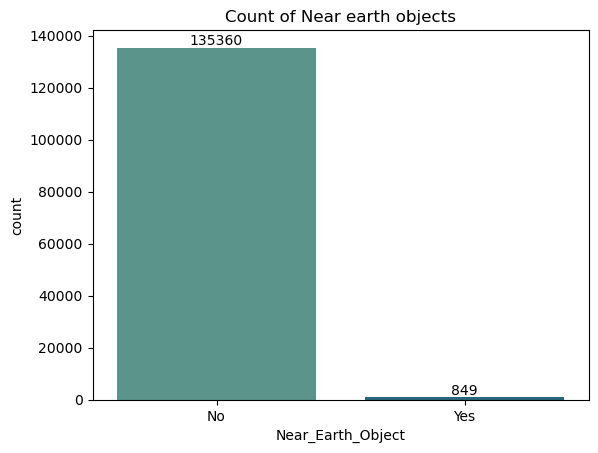

In [22]:
ax = sns.countplot(df,x='Near_Earth_Object', palette='crest')
for container in ax.containers:
    ax.bar_label(container)
ax.set_xticklabels(['No','Yes'])
plt.title('Count of Near earth objects')
plt.show();

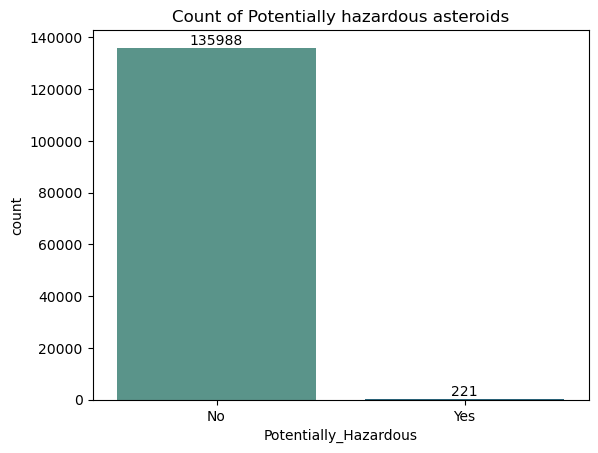

In [23]:
ax = sns.countplot(df,x='Potentially_Hazardous', palette='crest')
for container in ax.containers:
    ax.bar_label(container)
ax.set_xticklabels(['No','Yes'])
plt.title('Count of Potentially hazardous asteroids')
plt.show();

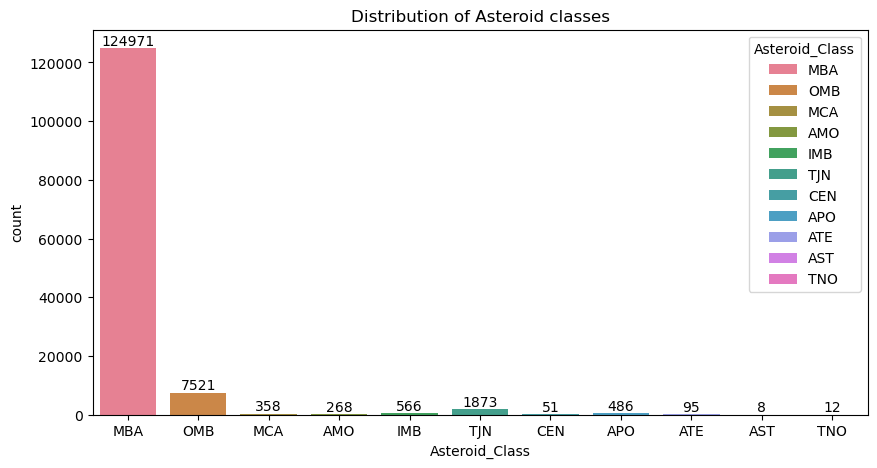

In [25]:
plt.figure(figsize=(10,5))
ax = sns.countplot(df,x='Asteroid_Class',hue='Asteroid_Class')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Distribution of Asteroid classes')
plt.legend(title='Asteroid_Class', loc='upper right', labels=['MBA','OMB','MCA','AMO','IMB','TJN','CEN','APO','ATE','AST','TNO'])
plt.show();

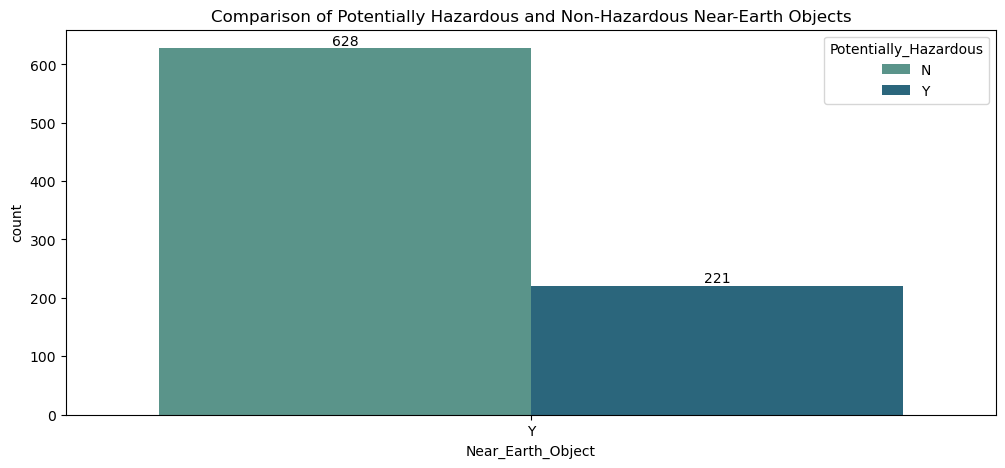

In [26]:
plt.figure(figsize=(12,5))
ax = sns.countplot(df[df.Near_Earth_Object == 'Y'],x='Near_Earth_Object',hue='Potentially_Hazardous', palette='crest')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Comparison of Potentially Hazardous and Non-Hazardous Near-Earth Objects')
plt.show();

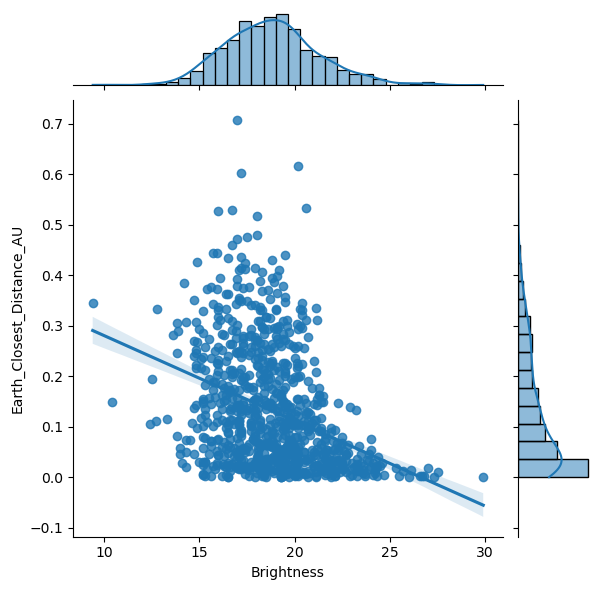

In [28]:
sns.jointplot(data = df[df.Near_Earth_Object == 'Y'], x="Brightness", y = "Earth_Closest_Distance_AU", kind='reg');

### Data splitting

In [15]:
y = df['Asteroid_Size_km(Diameter)']
X = df.drop(columns='Asteroid_Size_km(Diameter)')

In [16]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=24)
X_train.shape
X_test.shape
y_train.shape
y_test.shape

(108967, 16)

(27242, 16)

(108967,)

(27242,)

In [17]:
X_train.head()
X_test.head()

,Near_Earth_Object,Potentially_Hazardous,Brightness,Reflectivity,Orbit_Shape,Orbit_Distance_AU,Closest_Sun_Distance_AU,Orbit_Tilt_Degrees,Orbit_Angle_1_Degrees,Orbit_Angle_2_Degrees,Orbit_Angle_3_Degrees,Farthest_Sun_Distance_AU,Orbit_Speed_Degrees_Per_Day,Orbit_Period_Days,Earth_Closest_Distance_AU,Asteroid_Class
674417,N,N,15.200000,0.019000,0.121955,2.087811,1.833192,11.594150,304.696200,141.393449,186.715422,2.342430,0.326714,1101.882257,0.861522,MBA
44413,N,N,14.700000,0.057000,0.197503,2.678629,2.149591,11.164821,200.044171,138.580234,7.378144,3.207668,0.224820,1601.280310,1.155980,MBA
372087,N,N,16.400000,0.040000,0.068673,3.142562,2.926753,2.320521,190.835200,188.321476,33.688898,3.358372,0.176921,2034.812073,1.928650,MBA
227953,N,N,14.600000,0.033000,0.205031,3.080757,2.449108,25.757320,54.629516,186.315899,138.189428,3.712407,0.182271,1975.079683,1.438370,MBA
150222,N,N,16.400000,0.065000,0.161126,2.331894,1.956165,2.579229,220.945637,90.940426,90.426704,2.707624,0.276784,1300.653960,0.944046,MBA


,Near_Earth_Object,Potentially_Hazardous,Brightness,Reflectivity,Orbit_Shape,Orbit_Distance_AU,Closest_Sun_Distance_AU,Orbit_Tilt_Degrees,Orbit_Angle_1_Degrees,Orbit_Angle_2_Degrees,Orbit_Angle_3_Degrees,Farthest_Sun_Distance_AU,Orbit_Speed_Degrees_Per_Day,Orbit_Period_Days,Earth_Closest_Distance_AU,Asteroid_Class
672669,Y,N,22.400000,0.224000,0.151896,1.195152,1.013613,15.477563,47.806602,140.774523,282.744619,1.376690,0.754344,477.235827,0.033911,APO
89734,N,N,14.500000,0.074000,0.122216,3.070014,2.694808,6.619614,95.773182,114.760829,68.953728,3.445220,0.183229,1964.757797,1.697480,MBA
52279,N,N,14.300000,0.089000,0.318610,2.566883,1.749049,19.730344,0.899584,325.016252,180.894104,3.384716,0.239660,1502.129650,0.770127,MBA
30006,N,N,15.900000,0.046000,0.179938,2.210759,1.812960,3.756981,236.232436,42.302450,307.678688,2.608558,0.299842,1200.633481,0.798727,MBA
66631,N,N,13.800000,0.291000,0.145427,2.541598,2.171981,12.856771,328.419571,268.903390,165.540707,2.911215,0.243245,1479.989742,1.206630,MBA


In [18]:
y_train.head()
y_test.head()

674417   2.633000
44413    7.320000
372087   4.019000
227953   8.774000
150222   2.861000
Name: Asteroid_Size_km(Diameter), dtype: float64

672669   0.097000
89734    7.077000
52279    6.967000
30006    4.106000
66631    4.786000
Name: Asteroid_Size_km(Diameter), dtype: float64

In [19]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 108967 entries, 674417 to 904
Data columns (total 16 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Near_Earth_Object            108967 non-null  object 
 1   Potentially_Hazardous        108967 non-null  object 
 2   Brightness                   108967 non-null  float64
 3   Reflectivity                 108967 non-null  float64
 4   Orbit_Shape                  108967 non-null  float64
 5   Orbit_Distance_AU            108967 non-null  float64
 6   Closest_Sun_Distance_AU      108967 non-null  float64
 7   Orbit_Tilt_Degrees           108967 non-null  float64
 8   Orbit_Angle_1_Degrees        108967 non-null  float64
 9   Orbit_Angle_2_Degrees        108967 non-null  float64
 10  Orbit_Angle_3_Degrees        108967 non-null  float64
 11  Farthest_Sun_Distance_AU     108967 non-null  float64
 12  Orbit_Speed_Degrees_Per_Day  108967 non-null  float64
 13  Or

In [38]:
df.describe()

,Brightness,Asteroid_Size_km(Diameter),Reflectivity,Orbit_Shape,Orbit_Distance_AU,Closest_Sun_Distance_AU,Orbit_Tilt_Degrees,Orbit_Angle_1_Degrees,Orbit_Angle_2_Degrees,Orbit_Angle_3_Degrees,Farthest_Sun_Distance_AU,Orbit_Speed_Degrees_Per_Day,Orbit_Period_Days,Earth_Closest_Distance_AU
count,136209.000000,136209.000000,136209.000000,136209.000000,136209.000000,136209.000000,136209.000000,136209.000000,136209.000000,136209.000000,136209.000000,136209.000000,136209.000000,136209.000000
mean,15.134388,5.506429,0.130205,0.145660,2.819158,2.406130,10.295360,169.729893,181.808169,184.529202,3.232187,0.219086,1787.231375,1.423858
std,1.366614,9.425164,0.109971,0.077464,1.495980,0.516931,6.812632,102.715175,103.516287,105.632553,2.839820,0.056912,8965.839867,0.513029
min,3.000000,0.002500,0.001000,0.000060,0.626210,0.081820,0.022056,0.000418,0.000130,0.005112,0.999954,0.000135,180.999945,0.000027
25%,14.400000,2.780000,0.053000,0.089878,2.542856,2.072478,5.088142,82.276476,91.903488,91.647097,2.871056,0.181012,1481.088579,1.086220
50%,15.200000,3.972000,0.079000,0.138919,2.754950,2.368605,9.335690,160.301343,183.509496,188.275290,3.173515,0.215543,1670.202045,1.389580
75%,16.000000,5.765000,0.188000,0.191174,3.095029,2.688275,13.670331,255.961202,271.642281,277.821001,3.472570,0.243064,1988.819671,1.702400
max,29.900000,939.400000,1.000000,0.983789,376.133297,40.318477,170.334595,359.999793,359.998075,391.682098,746.169105,1.988951,2664471.618871,39.360300


In [20]:
transformer = ColumnTransformer(transformers=[('t1',RobustScaler(),make_column_selector(dtype_include=['float'])),('t2',OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=np.nan),make_column_selector(dtype_include=['object']))])
X_train_trans = pd.DataFrame(transformer.fit_transform(X_train),columns = transformer.feature_names_in_)
X_test_trans = pd.DataFrame(transformer.transform(X_test),columns = transformer.feature_names_in_)

In [21]:
X_train_trans.shape

(108967, 16)

In [22]:
pipe=Pipeline(steps=[("t1",ColumnTransformer(transformers=[("t1",OrdinalEncoder(),[0,1,15]),("t2",RobustScaler(),[2,3,4,5,6,7,8,9,10,11,12,13,14])])),("t3",KNeighborsRegressor())])

In [23]:
pipe.fit(X_train,y_train)

Pipeline(steps=[('t1',
                 ColumnTransformer(transformers=[('t1', OrdinalEncoder(),
                                                  [0, 1, 15]),
                                                 ('t2', RobustScaler(),
                                                  [2, 3, 4, 5, 6, 7, 8, 9, 10,
                                                   11, 12, 13, 14])])),
                ('t3', KNeighborsRegressor())])

In [24]:
y_pred = pipe.predict(X_test)

In [25]:
y_train_pred = pipe.predict(X_train)
mae_train = mean_absolute_error(y_train,y_train_pred)
mae_train

0.606626341920031

In [26]:
mae = mean_absolute_error(y_pred,y_test)
mae

0.7256136333602524

In [27]:
mse = mean_squared_error(y_pred,y_test)
mse

8.78053936087365

In [28]:
r2 = r2_score(y_pred,y_test)
r2

0.8440043394317254

In [29]:
pipe_dtr = Pipeline(steps=[("t1",ColumnTransformer(transformers=[("t1",OrdinalEncoder(),[0,1,15]),("t2",RobustScaler(),[2,3,4,5,6,7,8,9,10,11,12,13,14])])),("t3",DecisionTreeRegressor())])

In [30]:
pipe_dtr.fit(X_train,y_train)

Pipeline(steps=[('t1',
                 ColumnTransformer(transformers=[('t1', OrdinalEncoder(),
                                                  [0, 1, 15]),
                                                 ('t2', RobustScaler(),
                                                  [2, 3, 4, 5, 6, 7, 8, 9, 10,
                                                   11, 12, 13, 14])])),
                ('t3', DecisionTreeRegressor())])

In [31]:
y_pred = pipe_dtr.predict(X_test)

In [32]:
mae = mean_absolute_error(y_pred,y_test)
mae

0.6033096688936201

In [33]:
mse = mean_squared_error(y_pred,y_test)
mse

3.6593378411276696

In [34]:
r2 = r2_score(y_pred,y_test)
r2

0.9474915251302534

### Pickle file using decision tree

In [35]:
with open('asteroids_dtr.pkl','wb') as f:
    pickle.dump(pipe_dtr,f)

pipe_knn = Pipeline(steps=[
    ("preprocessor", ColumnTransformer(transformers=[
        ('scale', RobustScaler(), [2,3,4,5,6,7,8,9,10,11,12,13,14]),
        ('encode', OrdinalEncoder(), [0,1,15])
    ], remainder='passthrough')),
    ("knn", KNeighborsRegressor())
])

param_grid_knn = {
    'knn__n_neighbors': np.arange(5, 11),
    'knn__weights': ['uniform', 'distance']
}

grid_search = GridSearchCV(pipe_knn, param_grid_knn, cv=5, scoring='r2', n_jobs=-1)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validated training accuracy:", grid_search.best_score_)

y_pred = grid_search.best_estimator_.predict(X_test)

print("Test set accuracy:", accuracy_score(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))